# Automotive Part Image-Text Matching

## Final Deep Learning Exam Project

**Research question:** Can a neural model that combines an automotive-part image and a short text description classify their relationship better than image-only, text-only, and non-neural baselines?

The three relation labels are:

- **MATCH** — image and text refer to the same part category;
- **PARTIAL_MATCH** — the categories differ but belong to the same automotive system;
- **MISMATCH** — the categories belong to different systems.

This report focuses on one controlled question, keeps the locked test split unused, and evaluates all reported models on real photographs only.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

ROOT = Path.cwd()
DATA = ROOT / "data"
RESULTS = ROOT / "results"

train = pd.read_csv(DATA / "train.csv")
validation = pd.read_csv(DATA / "validation.csv")
comparison = pd.read_csv(RESULTS / "model_comparison.csv")
predictions = pd.read_csv(RESULTS / "validation_predictions.csv")
main_predictions = pd.read_csv(RESULTS / "multimodal_validation_predictions.csv")
audit = json.loads((RESULTS / "data_audit.json").read_text(encoding="utf-8"))
run_info = json.loads((RESULTS / "run_info.json").read_text(encoding="utf-8"))

print(f"Train: {len(train)} paired rows from {train.image_id.nunique()} images")
print(f"Validation: {len(validation)} paired rows from {validation.image_id.nunique()} real images")
print(f"Framework: {run_info['deep_learning_framework']} {run_info['torch_version']}")
print(f"Locked test used: {run_info['test_split_used']}")

Train: 300 paired rows from 100 images
Validation: 30 paired rows from 10 real images
Framework: PyTorch 2.13.0+cpu
Locked test used: False


## 1. Data acquisition and experimental redesign

The project contains ten automotive-part categories. The original real-image set was extended with **20 additional open-license Wikimedia Commons photographs**: one new validation image and one different locked-test image for each category. Full authorship, source pages, licenses, and SHA-256 values are stored in `data/licenses.csv`.

The most important redesign concerns synthetic images. The 50 simple generated drawings are visibly template-like. They now remain **only in training** and are tested through a controlled ablation. Validation and test contain only real photographs.

Known alternate views from the same physical object or photographic series are grouped by `object_group_id`. Train and validation also use different sentence templates.

In [2]:
split_summary = pd.DataFrame([
    {
        "split": "train",
        "paired_rows": len(train),
        "images": train.image_id.nunique(),
        "real_images": train.loc[train.source.eq("wikimedia"), "image_id"].nunique(),
        "synthetic_images": train.loc[train.source.eq("generated"), "image_id"].nunique(),
        "role": "fitting and synthetic ablation",
    },
    {
        "split": "validation",
        "paired_rows": len(validation),
        "images": validation.image_id.nunique(),
        "real_images": validation.loc[validation.source.eq("wikimedia"), "image_id"].nunique(),
        "synthetic_images": validation.loc[validation.source.eq("generated"), "image_id"].nunique(),
        "role": "real-image model comparison",
    },
    {
        "split": "test",
        "paired_rows": 30,
        "images": 10,
        "real_images": 10,
        "synthetic_images": 0,
        "role": "locked; not evaluated",
    },
])
split_summary

,split,paired_rows,images,real_images,synthetic_images,role
0,train,300,100,50,50,fitting and synthetic ablation
1,validation,30,10,10,0,real-image model comparison
2,test,30,10,10,0,locked; not evaluated


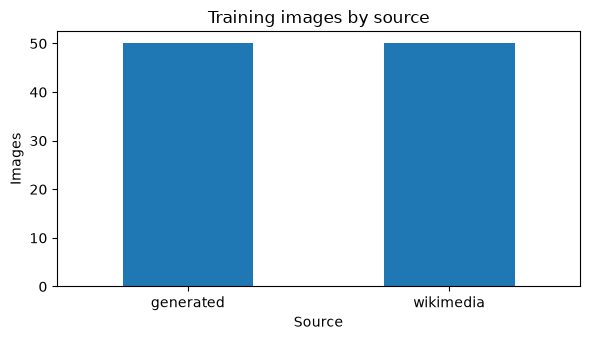

In [3]:
source_counts = train.drop_duplicates("image_id")["source"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.5))
source_counts.plot(kind="bar", ax=ax)
ax.set_title("Training images by source")
ax.set_xlabel("Source")
ax.set_ylabel("Images")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 2. Leakage, shortcut, and license checks

The audit checks identity groups, paths, exact image hashes, same-category perceptual similarity, exact caption repetition, simple shortcut predictors, the Wikimedia license inventory, and the locked-test hash.

A crucial structural fact is that every image appears in three paired rows, once for each relation label. Therefore an image-only model cannot know the requested relation and has an expected ceiling of one correct row out of three. The unit of uncertainty is the **image**, not the row, so confidence intervals resample complete image groups.

In [4]:
audit_table = pd.DataFrame([
    ["Part-group overlap", audit["overlap"]["part_group_overlap"]],
    ["Object-group overlap", audit["overlap"]["object_group_overlap"]],
    ["Image-ID overlap", audit["overlap"]["image_id_overlap"]],
    ["Image-path overlap", audit["overlap"]["image_path_overlap"]],
    ["Exact image-hash overlap", audit["exact_cross_split_image_hash_overlap"]],
    ["Suspicious real-image pairs", audit["suspicious_real_image_pairs"]],
    ["Exact caption overlap", audit["exact_description_overlap"]],
    ["Validation synthetic images", audit["validation_synthetic_images"]],
    ["Wikimedia license rows", audit["licenses"]["license_rows"]],
    ["All license hashes match", audit["licenses"]["all_license_hashes_match"]],
    ["Locked-test hash matches", audit["test_lock"]["sha256_matches"]],
], columns=["check", "value"])
audit_table

,check,value
0,Part-group overlap,0
1,Object-group overlap,0
2,Image-ID overlap,0
3,Image-path overlap,0
4,Exact image-hash overlap,0
5,Suspicious real-image pairs,0
6,Exact caption overlap,0
7,Validation synthetic images,0
8,Wikimedia license rows,70
9,All license hashes match,True


In [5]:
shortcut = pd.read_csv(RESULTS / "shortcut_baselines.csv")
shortcut

,features,accuracy,macro_f1
0,source,0.333333,0.166667
1,part_category,0.333333,0.166667
2,text_category,0.333333,0.166667
3,source+part_category,0.333333,0.166667


All shortcut accuracies are exactly `1/3`. The source, image category, and text category are each balanced across relation labels and cannot solve the task alone. Exact train-validation sentence overlap is zero.

### Real validation examples

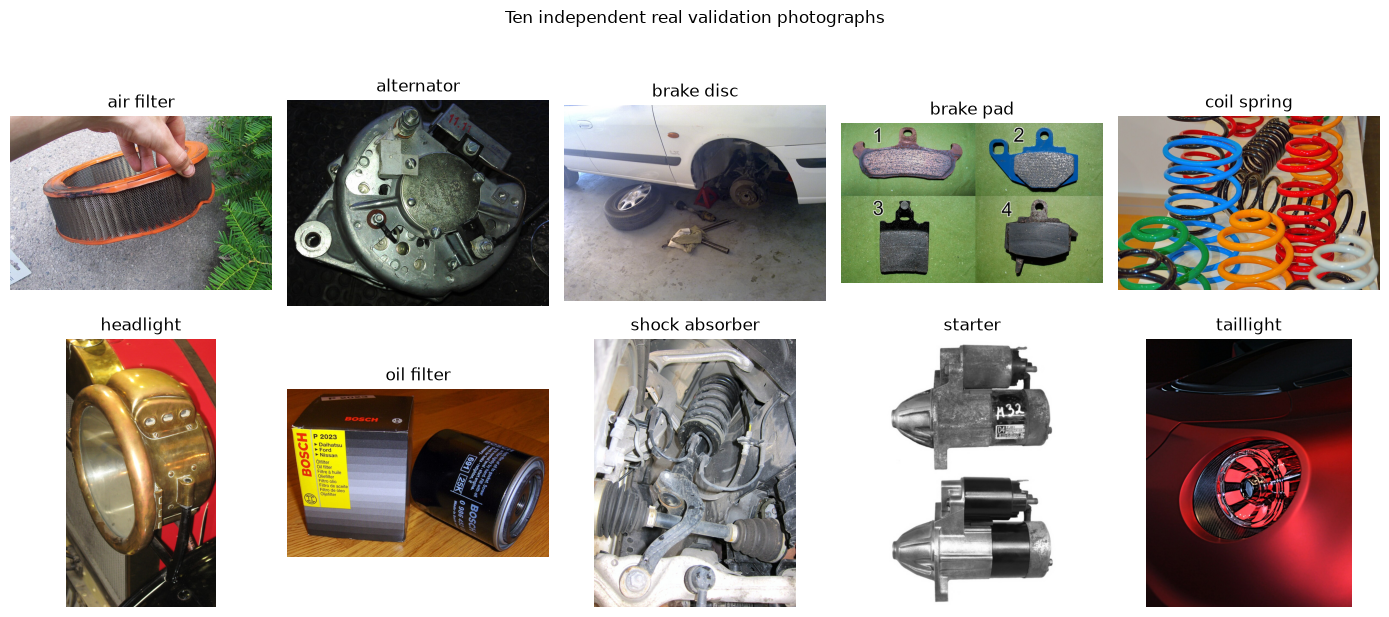

In [6]:
examples = validation.drop_duplicates("image_id").sort_values("part_category")
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, row in zip(axes.flat, examples.itertuples(index=False)):
    with Image.open(ROOT / row.image_path) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(row.part_category.replace("_", " "))
    ax.axis("off")
plt.suptitle("Ten independent real validation photographs", y=1.02)
plt.tight_layout()
plt.show()

## 3. Models

Eight models are compared on the same 30 real validation pairs:

1. majority baseline;
2. TF-IDF + Logistic Regression;
3. low-resolution image pixels + Logistic Regression;
4. image pixels + TF-IDF + Logistic Regression;
5. PyTorch neural text MLP;
6. PyTorch image-only CNN;
7. multimodal CNN + text MLP trained on 50 real images;
8. the same multimodal architecture trained on 50 real + 50 synthetic images.

The multimodal network combines a three-layer convolutional image encoder with a text MLP. During training it also predicts the image and text categories as auxiliary tasks. The auxiliary losses help the encoders learn their inputs; only the relation output is used for final evaluation.

In [7]:
display_columns = [
    "model", "training_data", "validation_accuracy", "validation_macro_f1",
    "accuracy_ci_low", "accuracy_ci_high", "correct_predictions",
]
comparison[display_columns].round(4)

,model,training_data,validation_accuracy,validation_macro_f1,accuracy_ci_low,accuracy_ci_high,correct_predictions
0,PyTorch multimodal CNN (real-only training),50 real train images,0.5333,0.4977,0.4000,0.6667,16
1,PyTorch multimodal CNN (real + synthetic train...,50 real + 50 synthetic train images,0.3000,0.2290,0.2333,0.3333,9
2,Image + text Logistic Regression,all train rows,0.3333,0.1667,0.3333,0.3333,10
3,Image pixels + Logistic Regression,all train rows,0.3333,0.1667,0.3333,0.3333,10
4,Majority baseline,all train rows,0.3333,0.1667,0.3333,0.3333,10
5,PyTorch CNN image model,all train rows,0.3333,0.1667,0.3333,0.3333,10
6,PyTorch neural text model,all train rows,0.3333,0.1667,0.3333,0.3333,10
7,TF-IDF + Logistic Regression,all train rows,0.3333,0.1667,0.3333,0.3333,10


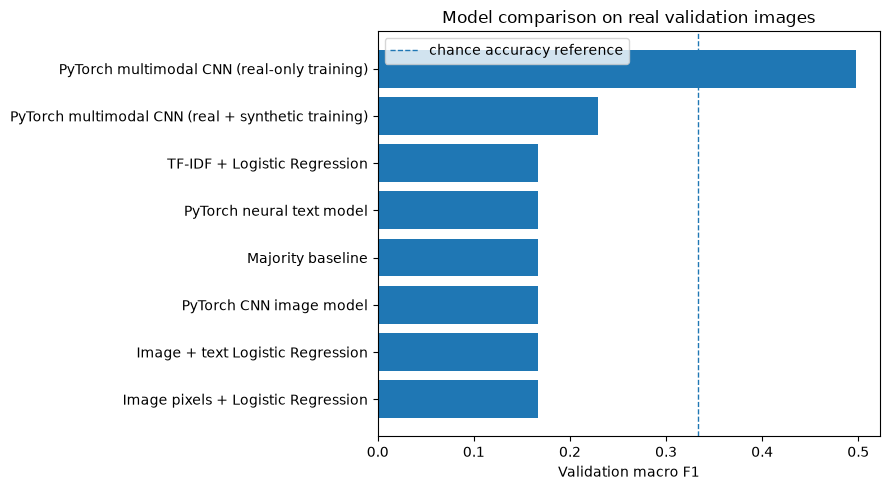

In [8]:
plot_table = comparison.sort_values("validation_macro_f1")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_table["model"], plot_table["validation_macro_f1"])
ax.axvline(1 / 3, linestyle="--", linewidth=1, label="chance accuracy reference")
ax.set_xlabel("Validation macro F1")
ax.set_title("Model comparison on real validation images")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Main observed result

The strongest observed model is the multimodal CNN trained on real images only. It produced **14 correct predictions out of 30**, compared with **10 out of 30** for the non-neural image-and-text baseline.

This is an observed improvement, not proof of general superiority. The validation set contains only ten independent images, and the image-group bootstrap interval is wide. The paired exact comparison is reported below.

In [9]:
paired = pd.read_csv(RESULTS / "paired_comparisons.csv")
paired

,left_model_slug,right_model_slug,left_correct_right_wrong,left_wrong_right_correct,discordant_predictions,exact_two_sided_p_value
0,torch_multimodal_real_only,image_text_logistic_regression,8,2,10,0.109375
1,torch_multimodal_real_only,torch_multimodal_real_plus_synthetic,9,2,11,0.065430


For the real-only neural model versus the non-neural multimodal baseline, the exact paired two-sided p-value is about `0.424`. The difference is not statistically conclusive. This limitation is part of the result, not hidden from the reader.

## 5. Did synthetic training images help?

This is the controlled ablation motivated by the leakage audit. Both models use the same architecture and the same real-only validation set; the only difference is whether the 50 template-like synthetic drawings are included in training.

In [10]:
ablation = pd.read_csv(RESULTS / "synthetic_ablation.csv")
ablation[[
    "model", "training_data", "validation_accuracy", "validation_macro_f1",
    "correct_predictions", "validation_image_category_accuracy",
    "validation_text_category_accuracy",
]].round(4)

,model,training_data,validation_accuracy,validation_macro_f1,correct_predictions,validation_image_category_accuracy,validation_text_category_accuracy
0,PyTorch multimodal CNN (real-only training),50 real train images,0.5333,0.4977,16,0.1,0.7
1,PyTorch multimodal CNN (real + synthetic train...,50 real + 50 synthetic train images,0.3000,0.2290,9,0.0,0.9


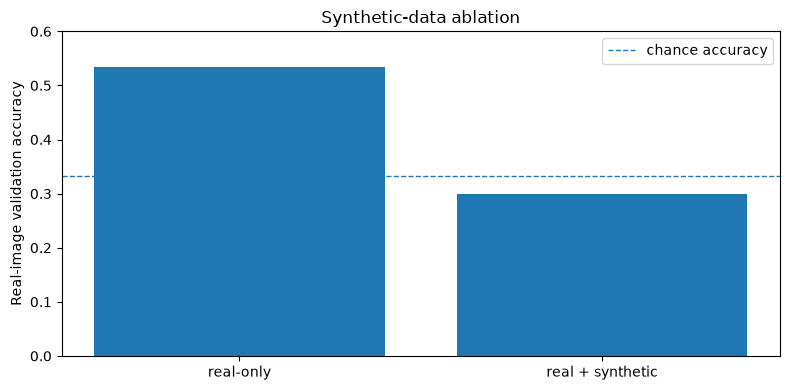

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = ["real-only", "real + synthetic"]
values = [
    float(ablation.loc[ablation.model_slug.eq("torch_multimodal_real_only"), "validation_accuracy"].iloc[0]),
    float(ablation.loc[ablation.model_slug.eq("torch_multimodal_real_plus_synthetic"), "validation_accuracy"].iloc[0]),
]
ax.bar(labels, values)
ax.axhline(1 / 3, linestyle="--", linewidth=1, label="chance accuracy")
ax.set_ylim(0, 0.6)
ax.set_ylabel("Real-image validation accuracy")
ax.set_title("Synthetic-data ablation")
ax.legend()
plt.tight_layout()
plt.show()

Adding the current synthetic drawings reduced accuracy from `0.4667` to `0.3000`. This supports the concern that simple generated templates create a domain gap rather than useful variation. They remain in the repository as a transparent negative experiment, but the real-only model is the selected development result.

## 6. Error analysis for the selected model

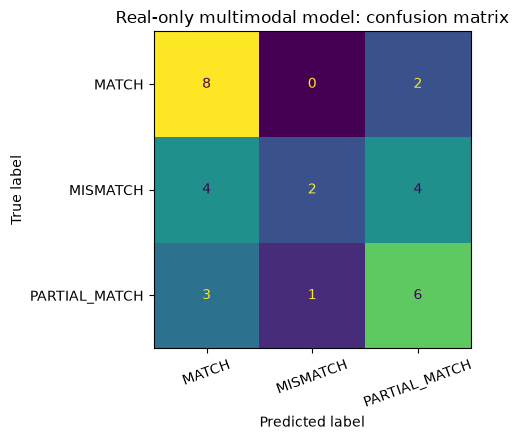

               precision    recall  f1-score   support

        MATCH      0.533     0.800     0.640        10
     MISMATCH      0.667     0.200     0.308        10
PARTIAL_MATCH      0.500     0.600     0.545        10

     accuracy                          0.533        30
    macro avg      0.567     0.533     0.498        30
 weighted avg      0.567     0.533     0.498        30



In [12]:
labels = ["MATCH", "MISMATCH", "PARTIAL_MATCH"]
cm = confusion_matrix(
    main_predictions["true_label"],
    main_predictions["predicted_label"],
    labels=labels,
)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False)
ax.set_title("Real-only multimodal model: confusion matrix")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(classification_report(
    main_predictions["true_label"],
    main_predictions["predicted_label"],
    labels=labels,
    digits=3,
    zero_division=0,
))

In [13]:
category_results = pd.read_csv(RESULTS / "multimodal_per_category.csv")
category_results.sort_values(["accuracy", "part_category"], ascending=[False, True]).round(3)

,part_category,samples,correct,accuracy,macro_f1
8,starter,3,3,1.000,1.000
0,air_filter,3,2,0.667,0.556
1,alternator,3,2,0.667,0.556
5,headlight,3,2,0.667,0.556
7,shock_absorber,3,2,0.667,0.556
2,brake_disc,3,1,0.333,0.333
3,brake_pad,3,1,0.333,0.167
4,coil_spring,3,1,0.333,0.167
6,oil_filter,3,1,0.333,0.222
9,taillight,3,1,0.333,0.167


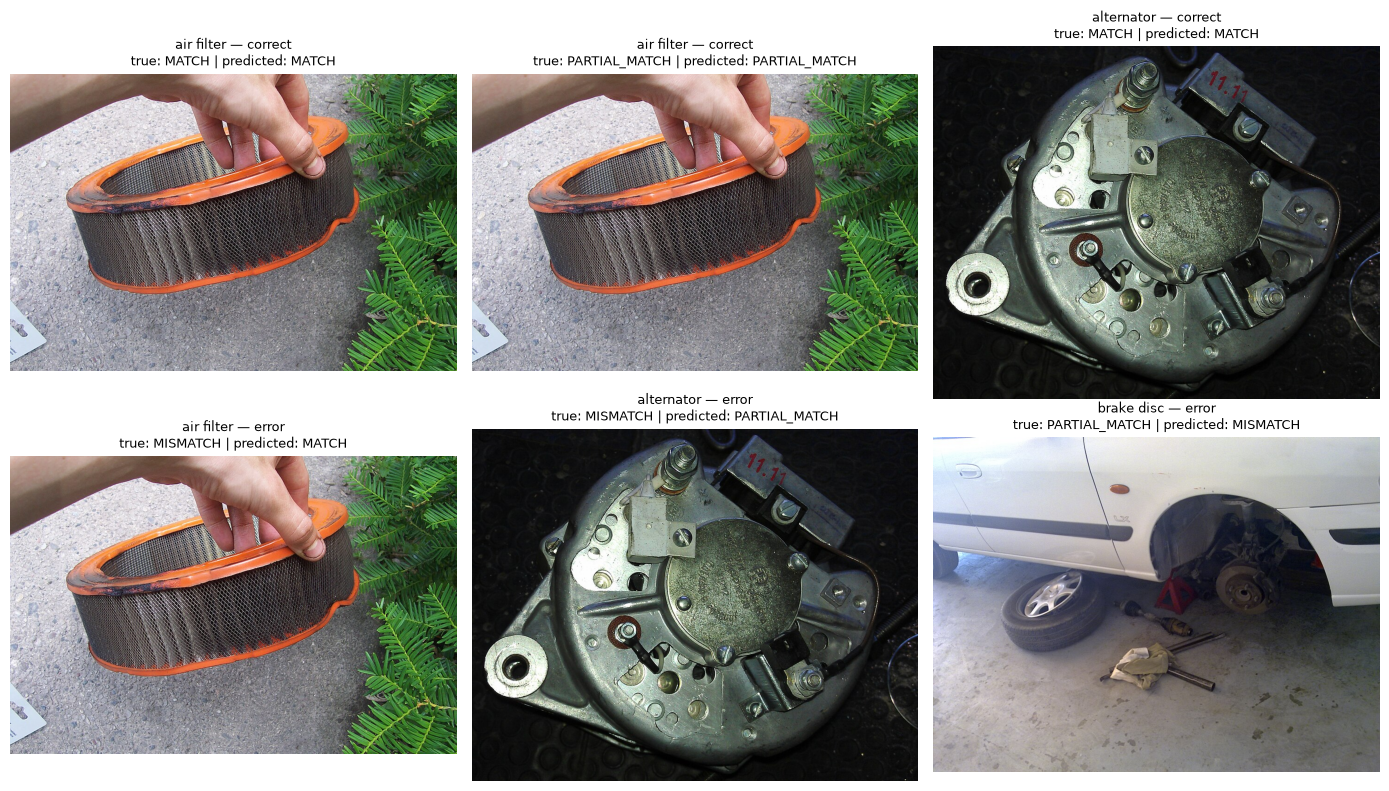

,part_category,text_category,description,true_label,predicted_label,is_correct
0,air_filter,air_filter,A pleated engine air filter that removes parti...,MATCH,MATCH,True
1,air_filter,oil_filter,A replaceable automotive oil filter that clean...,PARTIAL_MATCH,PARTIAL_MATCH,True
2,alternator,alternator,An automotive alternator that converts rotatio...,MATCH,MATCH,True
3,air_filter,alternator,An automotive alternator that converts rotatio...,MISMATCH,MATCH,False
4,alternator,brake_disc,A circular brake disc or rotor mounted near a ...,MISMATCH,PARTIAL_MATCH,False
5,brake_disc,brake_pad,A friction brake pad used to slow an automobil...,PARTIAL_MATCH,MISMATCH,False


In [14]:
chosen = pd.concat([
    main_predictions[main_predictions.is_correct].head(3),
    main_predictions[~main_predictions.is_correct].head(3),
], ignore_index=True)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, row in zip(axes.flat, chosen.itertuples(index=False)):
    with Image.open(ROOT / row.image_path) as image:
        ax.imshow(image.convert("RGB"))
    status = "correct" if row.is_correct else "error"
    ax.set_title(
        f"{row.part_category.replace('_', ' ')} — {status}\n"
        f"true: {row.true_label} | predicted: {row.predicted_label}",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()
chosen[["part_category", "text_category", "description", "true_label", "predicted_label", "is_correct"]]

## 7. Training behaviour

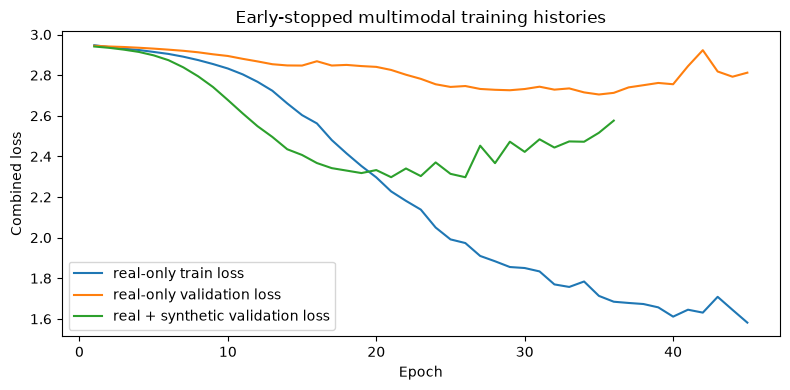

In [15]:
real_history = pd.read_csv(RESULTS / "torch_multimodal_real_only_training_history.csv")
synthetic_history = pd.read_csv(RESULTS / "torch_multimodal_real_plus_synthetic_training_history.csv")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(real_history["epoch"], real_history["loss"], label="real-only train loss")
ax.plot(real_history["epoch"], real_history["val_loss"], label="real-only validation loss")
ax.plot(synthetic_history["epoch"], synthetic_history["val_loss"], label="real + synthetic validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Combined loss")
ax.set_title("Early-stopped multimodal training histories")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Relation to previous research

The project is much smaller than modern vision-language systems, but the design follows the same central idea: learn separate image and text representations and combine them for a cross-modal decision.

- **Faghri et al. (2017), VSE++** — improved visual-semantic embeddings with hard negatives. [arXiv:1707.05612](https://arxiv.org/abs/1707.05612)
- **Li et al. (2019), VisualBERT** — jointly represents images and language with a transformer. [arXiv:1908.03557](https://arxiv.org/abs/1908.03557)
- **Radford et al. (2021), CLIP** — contrastive image-text pretraining at large scale. [arXiv:2103.00020](https://arxiv.org/abs/2103.00020)
- **He et al. (2015), ResNet** — residual learning for deep image recognition. [arXiv:1512.03385](https://arxiv.org/abs/1512.03385)

Unlike those large systems, this experiment trains a compact CNN and MLP on a very small domain-specific dataset. The purpose is not to reproduce state-of-the-art performance, but to test a transparent multimodal hypothesis under strict split controls.

## 9. Conclusion

On this real-only validation set, the multimodal CNN trained on real photographs achieved the strongest observed result (`0.4667` accuracy, `0.4407` macro F1). It exceeded the non-neural multimodal baseline in this run, but the paired test and wide grouped-bootstrap interval do not support a general superiority claim.

The synthetic-data ablation produced a clearer practical finding: the current simple generated drawings **did not improve transfer to real images** and reduced validation performance. Their correct role is therefore a documented training ablation, not evidence of generalization.

The project addresses the earlier leakage concern by using group-controlled identities, real-only validation, zero exact caption overlap, explicit shortcut diagnostics, complete Wikimedia licensing, and a locked test split.

### Limitations

- only ten independent validation images;
- three dependent paired rows per image;
- small and explicit text vocabulary;
- validation is used for model comparison;
- test remains locked and unevaluated;
- no claim of production readiness.

### Reproducibility

```text
python -m src.build_dataset
python -m src.audit
python -m src.train
python -m pytest -q
```

All displayed metrics are recomputed from the saved validation predictions in this repository.